In [1]:
# Import analysis libraries and define shared paths and plot settings.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

RESULTS_DIR = Path('../results')
FIGURES_DIR = Path('.')
SAMPLES_PER_CASE = 801

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Times New Roman',
    'mathtext.it': 'Times New Roman:italic',
    'mathtext.bf': 'Times New Roman:bold',
})

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
# Read one COMSOL point-graph export and convert voltage from V to μV.
def read_simulated_signal(file_path):
    data = pd.read_csv(
        file_path,
        sep=r'\s+',
        comment='%',
        names=['solution_number', 'potential_v'],
    )
    return data['potential_v'].to_numpy() * 1e6

In [3]:
# Split a concatenated parameter sweep into one 801-sample trace per case.
def split_sweep(signal, number_of_cases):
    expected_samples = number_of_cases * SAMPLES_PER_CASE
    if signal.size != expected_samples:
        raise ValueError(f'Expected {expected_samples} samples, found {signal.size}.')
    return signal.reshape(number_of_cases, SAMPLES_PER_CASE)

In [4]:
# Return the difference between the maximum and minimum samples.
def peak_to_peak(signal):
    return np.ptp(signal)

## Pool size

,pool_side_length_m,vpp_uv
0,0.5,310.5
1,1.0,219.1
2,3.0,187.8
3,5.0,175.8
4,7.0,182.2
5,9.0,183.7


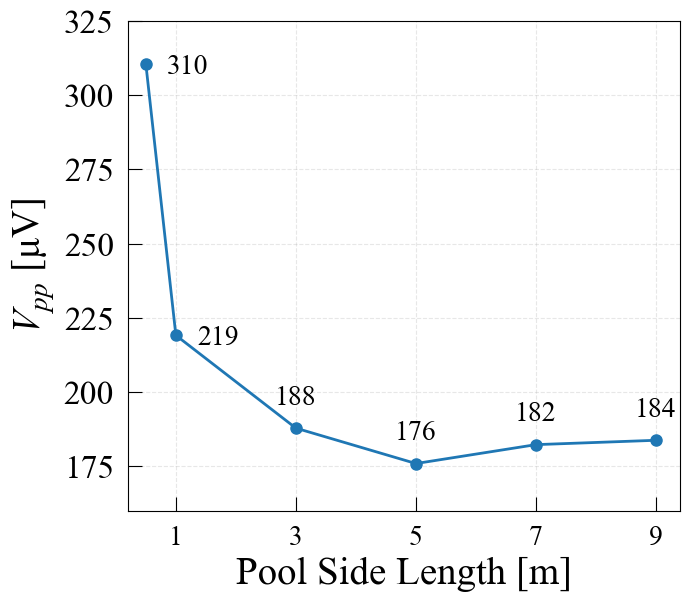

In [5]:
# Load the pool-size sweep and calculate Vpp for each side length.
pool_sizes_m = np.array([0.5, 1.0, 3.0, 5.0, 7.0, 9.0])
pool_size_signal = read_simulated_signal(RESULTS_DIR / 'pool_size_sweep_ecg.txt')
pool_size_traces = split_sweep(pool_size_signal, pool_sizes_m.size)
pool_size_vpp = np.array([peak_to_peak(trace) for trace in pool_size_traces])

# Display the numerical results.
pool_size_results = pd.DataFrame({
    'pool_side_length_m': pool_sizes_m,
    'vpp_uv': pool_size_vpp,
})
display(pool_size_results.round({'vpp_uv': 1}))

# Round the float values only for the integer labels shown in the plot.
pool_size_vpp_labels = [round(value) for value in pool_size_vpp]

# Plot pool side length against Vpp.
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(pool_sizes_m, pool_size_vpp, marker='o', linewidth=2, markersize=8, color='C0')
for index, (x_value, y_value, label) in enumerate(
    zip(pool_sizes_m, pool_size_vpp, pool_size_vpp_labels)
):
    if index in (0, 1):
        ax.text(x_value + 0.7, y_value - 3, str(label), ha='center', fontsize=20)
    else:
        ax.text(x_value, y_value + 8, str(label), ha='center', fontsize=20)
ax.set_xticks([1, 3, 5, 7, 9])
ax.set_xlim(0.2, 9.4)
ax.set_ylim(160, 325)
ax.tick_params(direction='in', length=10, pad=10, labelsize=24)
ax.tick_params(axis='x', labelsize=20)
ax.set_xlabel('Pool Side Length [m]', fontsize=28)
ax.set_ylabel(r'$V_{pp}$ [μV]', fontsize=28)
ax.grid(True, alpha=0.3, linestyle='--')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'pool_size.png', dpi=300)
plt.show()

## Water conductivity

In [6]:
# Inverse model used to fit conductivity against Vpp.
def inverse_model(x, k, e):
    return k / (x + e)

,water_conductivity_s_per_m,vpp_uv
0,0.01,325.1
1,0.02,269.4
2,0.03,227.9
3,0.04,198.1
4,0.05,176.5
5,0.06,157.0
6,0.07,142.7
7,0.08,130.9
8,0.09,120.4
9,0.10,111.3


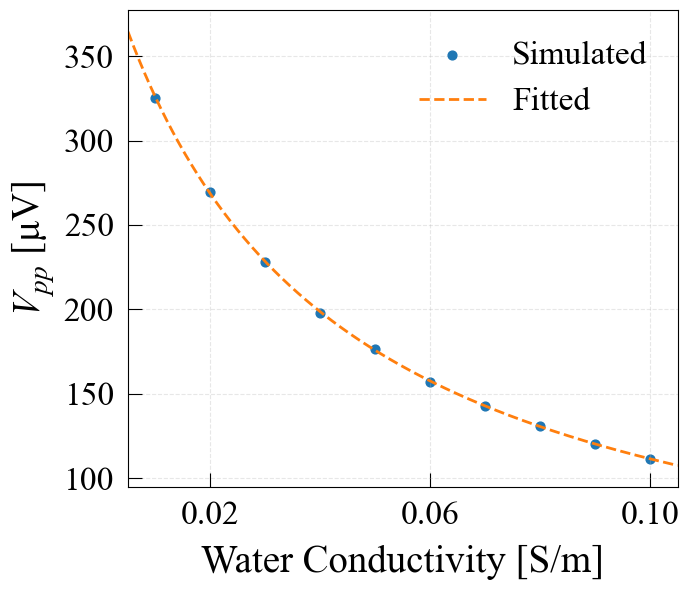

In [7]:
# Load the conductivity sweep and calculate Vpp for each conductivity.
water_conductivity_s_m = np.round(np.arange(0.01, 0.101, 0.01), 2)
conductivity_signal = read_simulated_signal(
    RESULTS_DIR / 'pool_water_conductivity_sweep_ecg.txt'
)
conductivity_traces = split_sweep(conductivity_signal, water_conductivity_s_m.size)
conductivity_vpp = np.array([peak_to_peak(trace) for trace in conductivity_traces])

# Display the numerical results.
water_conductivity_results = pd.DataFrame({
    'water_conductivity_s_per_m': water_conductivity_s_m,
    'vpp_uv': conductivity_vpp,
})
display(water_conductivity_results.round({'water_conductivity_s_per_m': 2, 'vpp_uv': 1}))

# Estimate k and e, then evaluate the response over 0.005–0.105 S/m.
fit_parameters, _ = curve_fit(inverse_model, water_conductivity_s_m, conductivity_vpp)
fit_x = np.linspace(0.005, 0.105, 1000)
fit_y = inverse_model(fit_x, *fit_parameters)

# Visualize conductivity-dependent Vpp with the inverse-model estimate.
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(water_conductivity_s_m, conductivity_vpp, s=40, label='Simulated')
ax.plot(fit_x, fit_y, 'C1--', linewidth=2, label='Fitted')
ax.legend(frameon=False, fontsize=24)
ax.set_xlim(0.005, 0.105)
ax.set_xticks([0.02, 0.06, 0.10])
ax.tick_params(direction='in', length=10, pad=10, labelsize=24)
ax.set_xlabel('Water Conductivity [S/m]', labelpad=10, fontsize=28)
ax.set_ylabel(r'$V_{pp}$ [μV]', fontsize=28)
ax.grid(True, alpha=0.3, linestyle='--')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'water_conductivity.png', dpi=300)
plt.show()

## Pool safety measures

In [8]:
# Calculate Vpp for the baseline, reinforced boundary, and ladder cases.
baseline_vpp = pool_size_vpp[np.where(pool_sizes_m == 5.0)[0][0]]
concrete_vpp = peak_to_peak(
    read_simulated_signal(RESULTS_DIR / 'pool_concrete_boundary_ecg.txt')
)
ladder_vpp = peak_to_peak(
    read_simulated_signal(RESULTS_DIR / 'pool_with_ladder.txt')
)

# Display the numerical results.
safety_measures = ['None', 'REINF', 'Ladder']
safety_vpp = np.array([baseline_vpp, concrete_vpp, ladder_vpp])
pool_safety_measures_results = pd.DataFrame({
    'pool_safety_measure': safety_measures,
    'vpp_uv': safety_vpp,
})
display(pool_safety_measures_results.round({'vpp_uv': 1}))

,pool_safety_measure,vpp_uv
0,None,175.8
1,REINF,171.7
2,Ladder,66.3
